# Bellabeat App — Análise de Comportamento de Usuários Fitness

**Google Data Analytics Capstone Project**

## Objetivo
Analisar dados de uso de dispositivos fitness de usuários FitBit para identificar
tendências de comportamento e aplicá-las ao **Bellabeat App**, orientando a estratégia
de marketing da empresa para mulheres interessadas em saúde e bem-estar.

## Metodologia
Este projeto segue o processo de análise de dados em 6 etapas:
- **Ask** — Definição da tarefa de negócio
- **Prepare** — Coleta e avaliação dos dados
- **Process** — Limpeza e transformação
- **Analyze** — Análise e descoberta de insights
- **Share** — Visualizações
- **Act** — Recomendações finais

## 1. Bibliotecas Utilizadas
Importando as bibliotecas necessárias para análise e visualização dos dados.

In [1]:
# Importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Prepare — Carregamento dos Dados

**Fonte:** FitBit Fitness Tracker Data (Kaggle, licença CC0 — domínio público)  
**Arquivos utilizados:**
- `dailyActivity_merged.csv` — atividade diária (passos, calorias, minutos ativos)
- `sleepDay_merged.csv` — registro de sono diário
- `hourlySteps_merged.csv` — passos por hora
- `weightLogInfo_merged.csv` — registros de peso e IMC

In [2]:
# Conectando ao Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

caminho = '/content/drive/MyDrive/CapstoneProject_BellaBeat_App/'

# Carregando os arquivos
daily  = pd.read_csv(caminho + 'dailyActivity_merged.csv',  sep=',')
sleep  = pd.read_csv(caminho + 'sleepDay_merged.csv',        sep=',')
hourly = pd.read_csv(caminho + 'hourlySteps_merged.csv',     sep=',')
weight = pd.read_csv(caminho + 'weightLogInfo_merged.csv',   sep=',')

# Verificando dimensões dos datasets
print("dailyActivity:", daily.shape)
print("sleepDay:",      sleep.shape)
print("hourlySteps:",   hourly.shape)
print("weightLogInfo:", weight.shape)

dailyActivity: (940, 15)
sleepDay: (413, 5)
hourlySteps: (22099, 3)
weightLogInfo: (67, 8)


## 2.1 Credibilidade dos Dados — Método ROCCC

| Critério | Avaliação | Observação |
|---|---|---|
| Reliable | ⚠️ Parcial | Apenas 33 usuários — amostra pequena |
| Original | ✅ Sim | Dados reais de dispositivos FitBit |
| Comprehensive | ⚠️ Parcial | Sem dados demográficos (idade, gênero) |
| Current | ❌ Não | Dados de 2016 — quase 10 anos atrás |
| Cited | ✅ Sim | Disponível no Kaggle com licença CC0 |

**Limitações identificadas:**
- Amostra de apenas 33 usuários — resultados não são generalizáveis
- Sem dados demográficos — não é possível confirmar se os usuários são mulheres
- Dados de 2016 — hábitos de uso podem ter mudado significativamente
- `weightLogInfo` com apenas 8 usuários — descartado das conclusões principais
## 2.2 Exploração Inicial dos Dados
Verificando estrutura, tipos de colunas e primeiras linhas do dataset principal.

In [4]:
# Explorando o dailyActivity
print("=== dailyActivity ===")
# Mostrar quantas colunas tem
print(daily.shape)
# Mostrar o tipo de cada coluna
print(daily.dtypes)
# Mostrar as 5 primeiras linhas
print(daily.head())

=== dailyActivity ===
(940, 15)
Id                            int64
ActivityDate                 object
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
dtype: object
           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  1503960366    4/12/2016       13162           8.50             8.50   
1  1503960366    4/13/2016       10735           6.97             6.97   
2  1503960366    4/14/2016       10460           6.74             6.74   
3  1503960366    4/15/2016        9762           6.28             6.28   
4  1503960366    4/16/2016       12669      

## 3. Process — Limpeza e Preparação dos Dados

Etapas realizadas:
- Conversão das colunas de data de `object` para `datetime`
- Remoção de 3 linhas duplicadas no dataset `sleepDay`
- Remoção da coluna `Fat` do dataset `weightLogInfo` (65 nulos em 67 linhas)
- Extração do dia da semana e hora para análises temporais
- Classificação dos usuários em níveis de atividade por faixa de passos diários
- União dos datasets `dailyActivity` e `sleepDay` para análises combinadas

In [5]:
# Corrigindo o tipo da coluna de data
daily['ActivityDate'] = pd.to_datetime(daily['ActivityDate'])
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'])
hourly['ActivityHour'] = pd.to_datetime(hourly['ActivityHour'])
weight['Date'] = pd.to_datetime(weight['Date'])

/tmp/ipykernel_4029/1465928924.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'])
/tmp/ipykernel_4029/1465928924.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourly['ActivityHour'] = pd.to_datetime(hourly['ActivityHour'])
/tmp/ipykernel_4029/1465928924.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weight['Date'] = pd.to_datetime(weight['Date'])


In [6]:
# Verificando valores nulos
print("=== Valores nulos por coluna ===")
print(daily.isnull().sum())
print("\n", sleep.isnull().sum())
print("\n", weight.isnull().sum())

# Verificando duplicatas
print("\n=== Duplicatas ===")
print("daily:", daily.duplicated().sum())
print("sleep:", sleep.duplicated().sum())
print("hourly:", hourly.duplicated().sum())
print("weight:", weight.duplicated().sum())

# Quantos usuários únicos em cada dataset?
print("\n=== Usuários únicos ===")
print("daily:", daily['Id'].nunique())
print("sleep:", sleep['Id'].nunique())
print("hourly:", hourly['Id'].nunique())
print("weight:", weight['Id'].nunique())

=== Valores nulos por coluna ===
Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

 Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64

 Id                 0
Date               0
WeightKg           0
WeightPounds       0
Fat               65
BMI                0
IsManualReport     0
LogId              0
dtype: int64

=== Duplicatas ===
daily: 0
sleep: 3
hourly: 0
weight: 0

=== Usuários únicos ===
daily: 33
sleep: 24
hourly: 33
weight: 8


In [7]:
# Removendo duplicatas do sleep
sleep = sleep.drop_duplicates()
print("Sleep após remoção de duplicatas:", sleep.shape)

Sleep após remoção de duplicatas: (410, 5)


In [8]:
# Removendo coluna Fat do weight (65 nulos em 67 linhas)
weight = weight.drop(columns=['Fat'])
print("Colunas do weight:", weight.columns.tolist())

Colunas do weight: ['Id', 'Date', 'WeightKg', 'WeightPounds', 'BMI', 'IsManualReport', 'LogId']


In [9]:
# Confirmando que ficou tudo certo
print("\nDuplicatas restantes:")
print("sleep:", sleep.duplicated().sum())


Duplicatas restantes:
sleep: 0


## 4. Analyze — Estatísticas e Insights

### 4.1 Estatísticas Descritivas Gerais
Calculando médias gerais para entender o comportamento típico dos usuários.

In [10]:
# Estatísticas descritivas principais
print("=== Médias gerais dos usuários ===")
print(f"Média de passos por dia: {daily['TotalSteps'].mean():.0f}")
print(f"Média de calorias por dia: {daily['Calories'].mean():.0f}")
print(f"Média de minutos sedentários: {daily['SedentaryMinutes'].mean():.0f}")
print(f"Média de minutos muito ativos: {daily['VeryActiveMinutes'].mean():.0f}")
print(f"Média de minutos levemente ativos: {daily['LightlyActiveMinutes'].mean():.0f}")

print("\n=== Sono ===")
print(f"Média de minutos dormindo: {sleep['TotalMinutesAsleep'].mean():.0f}")
print(f"Média de minutos na cama: {sleep['TotalTimeInBed'].mean():.0f}")
print(f"Média de tempo acordado na cama: {(sleep['TotalTimeInBed'] - sleep['TotalMinutesAsleep']).mean():.0f} minutos")

=== Médias gerais dos usuários ===
Média de passos por dia: 7638
Média de calorias por dia: 2304
Média de minutos sedentários: 991
Média de minutos muito ativos: 21
Média de minutos levemente ativos: 193

=== Sono ===
Média de minutos dormindo: 419
Média de minutos na cama: 458
Média de tempo acordado na cama: 39 minutos


### Insights — Atividade e Sono

- **Insight 1:** Média de 7.638 passos/dia — abaixo dos 10.000 recomendados pela OMS
- **Insight 2:** ~17 horas sedentárias por dia — comportamento predominantemente inativo
- **Insight 3:** Média de 7h de sono — dentro do recomendado (7-9h)
- **Insight 4:** 39 minutos acordado na cama — pode indicar dificuldade para dormir ou acordar


### 4.2 Padrões Temporais
Analisando em quais dias e horários os usuários são mais ativos.

In [11]:
# Extraindo dia da semana do dailyActivity
daily['DayOfWeek'] = daily['ActivityDate'].dt.day_name()

# Média de passos por dia da semana
steps_by_day = daily.groupby('DayOfWeek')['TotalSteps'].mean().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

print("=== Média de passos por dia da semana ===")
print(steps_by_day.round(0))

# Hora mais ativa do dia
hourly['Hour'] = hourly['ActivityHour'].dt.hour
steps_by_hour = hourly.groupby('Hour')['StepTotal'].mean()

print("\n=== Top 5 horas mais ativas ===")
print(steps_by_hour.sort_values(ascending=False).head())

=== Média de passos por dia da semana ===
DayOfWeek
Monday       7781.0
Tuesday      8125.0
Wednesday    7559.0
Thursday     7406.0
Friday       7448.0
Saturday     8153.0
Sunday       6933.0
Name: TotalSteps, dtype: float64

=== Top 5 horas mais ativas ===
Hour
18    599.169978
19    583.390728
17    550.232892
12    548.642082
14    540.513572
Name: StepTotal, dtype: float64


In [12]:
# Classificando usuários por nível de atividade
daily['ActivityLevel'] = pd.cut(daily['TotalSteps'],
    bins=[0, 5000, 7500, 10000, float('inf')],
    labels=['Sedentário', 'Pouco Ativo', 'Ativo', 'Muito Ativo'])

# Média de calorias por nível
calorias_nivel = daily.groupby('ActivityLevel')['Calories'].mean()
print("=== Calorias médias por nível de atividade ===")
print(calorias_nivel.round(0))

# Correlação entre passos e calorias
correlacao = daily['TotalSteps'].corr(daily['Calories'])
print(f"\nCorrelação passos x calorias: {correlacao:.2f}")

# Relação sono x tempo na cama
correlacao_sono = sleep['TotalMinutesAsleep'].corr(sleep['TotalTimeInBed'])
print(f"Correlação minutos dormindo x tempo na cama: {correlacao_sono:.2f}")

=== Calorias médias por nível de atividade ===
ActivityLevel
Sedentário     1858.0
Pouco Ativo    2254.0
Ativo          2461.0
Muito Ativo    2744.0
Name: Calories, dtype: float64

Correlação passos x calorias: 0.59
Correlação minutos dormindo x tempo na cama: 0.93


/tmp/ipykernel_4029/4187921414.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calorias_nivel = daily.groupby('ActivityLevel')['Calories'].mean()


### Insights — Padrões Temporais e Atividade

- **Insight 5:** Sábado e terça são os dias mais ativos (8.153 e 8.125 passos)
- **Insight 6:** Domingo é o dia mais sedentário (média de 6.933 passos)
- **Insight 7:** Picos de atividade às 12h e entre 17h–19h (horário pós-trabalho)


In [13]:
# Unindo daily com sleep para análise combinada
daily_sleep = pd.merge(daily, sleep,
                        left_on=['Id','ActivityDate'],
                        right_on=['Id','SleepDay'],
                        how='inner')

print(f"Registros combinados daily+sleep: {daily_sleep.shape[0]}")

# Correlação sedentarismo x sono
corr_sed_sleep = daily_sleep['SedentaryMinutes'].corr(daily_sleep['TotalMinutesAsleep'])
print(f"Correlação sedentarismo x minutos dormindo: {corr_sed_sleep:.2f}")

# Distribuição dos níveis de atividade
print("\n=== Distribuição dos níveis de atividade ===")
print(daily['ActivityLevel'].value_counts())

# Média de tempo acordado na cama por nível de atividade
daily_sleep['MinutesAwakeInBed'] = daily_sleep['TotalTimeInBed'] - daily_sleep['TotalMinutesAsleep']
awake_by_activity = daily_sleep.groupby('ActivityLevel')['MinutesAwakeInBed'].mean()
print("\n=== Minutos acordado na cama por nível de atividade ===")
print(awake_by_activity.round(0))

Registros combinados daily+sleep: 410
Correlação sedentarismo x minutos dormindo: -0.60

=== Distribuição dos níveis de atividade ===
ActivityLevel
Muito Ativo    303
Sedentário     226
Pouco Ativo    171
Ativo          163
Name: count, dtype: int64

=== Minutos acordado na cama por nível de atividade ===
ActivityLevel
Sedentário     40.0
Pouco Ativo    36.0
Ativo          32.0
Muito Ativo    43.0
Name: MinutesAwakeInBed, dtype: float64


/tmp/ipykernel_4029/270531419.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  awake_by_activity = daily_sleep.groupby('ActivityLevel')['MinutesAwakeInBed'].mean()


### Insights — Atividade, Calorias e Sono

- **Insight 8:** Correlação de **-0.60** entre sedentarismo e sono — mais sedentário, menos horas dormidas
- **Insight 9:** Usuários muito ativos queimam **47% mais calorias** que sedentários (2.744 vs 1.858 kcal)
- **Insight 10:** Sedentários ficam ~40 min acordados na cama — maior dificuldade para dormir
- **Nota:** A classificação "Muito Ativo" concentra mais registros pois os cortes de passos são generosos — limitação a mencionar no portfólio

## 5. Share — Visualizações
Criando gráficos para comunicar os principais insights de forma visual.

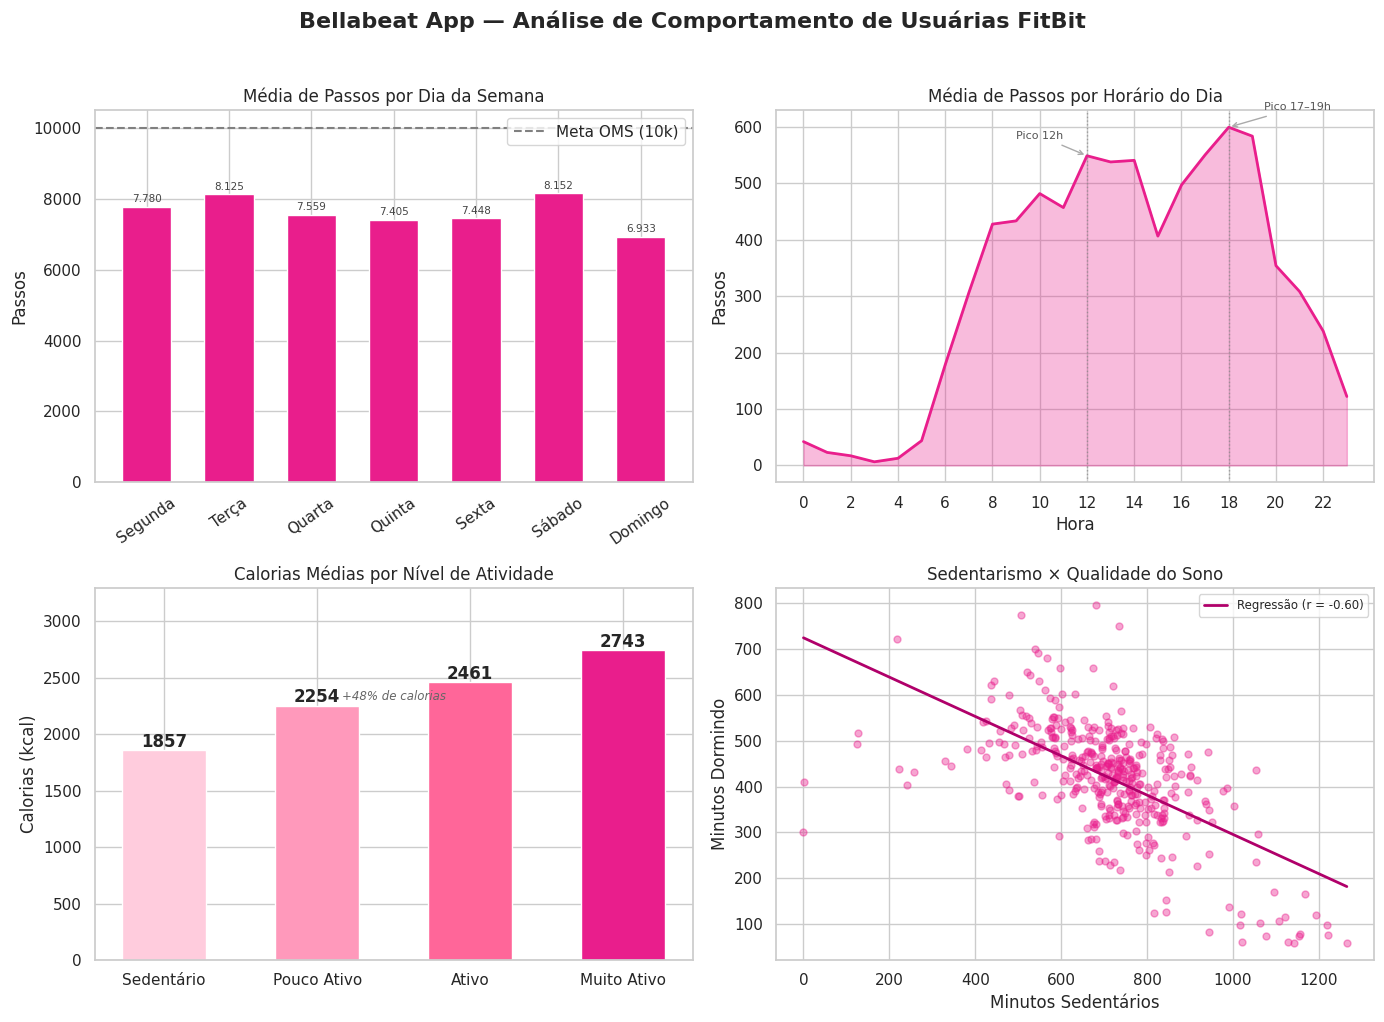

Gráfico salvo!


In [14]:
from scipy import stats

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bellabeat App — Análise de Comportamento de Usuárias FitBit',
             fontsize=16, fontweight='bold', y=1.02)

# --- Gráfico 1: Passos por dia da semana ---
dias_pt = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

steps_by_day = daily.groupby('DayOfWeek')['TotalSteps'].mean().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])
steps_by_day.index = dias_pt

bars1 = axes[0,0].bar(steps_by_day.index, steps_by_day.values, color='#E91E8C', width=0.6)
axes[0,0].axhline(y=10000, color='gray', linestyle='--', label='Meta OMS (10k)')
axes[0,0].set_title('Média de Passos por Dia da Semana')
axes[0,0].set_ylabel('Passos')
axes[0,0].tick_params(axis='x', rotation=35)
axes[0,0].legend()
for bar, val in zip(bars1, steps_by_day.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                   f'{int(val):,}'.replace(',', '.'),
                   ha='center', va='bottom', fontsize=7.5, color='#444444')

# --- Gráfico 2: Passos por horário ---
steps_by_hour = hourly.groupby('Hour')['StepTotal'].mean()
axes[0,1].plot(steps_by_hour.index, steps_by_hour.values, color='#E91E8C', linewidth=2)
axes[0,1].fill_between(steps_by_hour.index, steps_by_hour.values, alpha=0.3, color='#E91E8C')
axes[0,1].axvline(x=12, color='#888888', linestyle=':', linewidth=1, alpha=0.7)
axes[0,1].axvline(x=18, color='#888888', linestyle=':', linewidth=1, alpha=0.7)
axes[0,1].annotate('Pico 12h', xy=(12, steps_by_hour[12]),
                   xytext=(9, steps_by_hour[12] + 30),
                   fontsize=8, color='#555555',
                   arrowprops=dict(arrowstyle='->', color='#aaaaaa', lw=1))
axes[0,1].annotate('Pico 17–19h', xy=(18, steps_by_hour[18]),
                   xytext=(19.5, steps_by_hour[18] + 30),
                   fontsize=8, color='#555555',
                   arrowprops=dict(arrowstyle='->', color='#aaaaaa', lw=1))
axes[0,1].set_title('Média de Passos por Horário do Dia')
axes[0,1].set_xlabel('Hora')
axes[0,1].set_ylabel('Passos')
axes[0,1].set_xticks(range(0, 24, 2))

# --- Gráfico 3: Calorias por nível de atividade ---
cores = ['#ffccdd','#ff99bb','#ff6699','#E91E8C']
axes[1,0].bar(calorias_nivel.index, calorias_nivel.values, color=cores, width=0.55)
axes[1,0].set_title('Calorias Médias por Nível de Atividade')
axes[1,0].set_ylabel('Calorias (kcal)')
axes[1,0].set_ylim(0, calorias_nivel.max() * 1.2)
for i, v in enumerate(calorias_nivel.values):
    axes[1,0].text(i, v + 30, str(int(v)), ha='center', fontweight='bold')
sed = calorias_nivel.iloc[0]
ativo = calorias_nivel.iloc[-1]
pct = ((ativo - sed) / sed * 100)
axes[1,0].annotate(f'+{pct:.0f}% de calorias',
                   xy=(1.5, (sed + ativo) / 2),
                   ha='center', fontsize=8.5, color='#666666', style='italic')

# --- Gráfico 4: Sedentarismo x Sono com linha de regressão ---
x = daily_sleep['SedentaryMinutes']
y = daily_sleep['TotalMinutesAsleep']

axes[1,1].scatter(x, y, alpha=0.4, color='#E91E8C', s=25)

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_line = pd.Series([x.min(), x.max()])
axes[1,1].plot(x_line, slope * x_line + intercept,
               color='#b0006a', linewidth=2, label=f'Regressão (r = {r_value:.2f})')

axes[1,1].set_title('Sedentarismo × Qualidade do Sono')
axes[1,1].set_xlabel('Minutos Sedentários')
axes[1,1].set_ylabel('Minutos Dormindo')
axes[1,1].legend(fontsize=8.5)

plt.tight_layout()
plt.savefig('bellabeat_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo!")

## 6. Act — Recomendações para o Bellabeat App

Com base nos insights identificados, as recomendações a seguir visam orientar
a estratégia de marketing do **Bellabeat App**:

---

### Recomendação 1: Campanha "Mova-se para Dormir Melhor"
Os dados mostram correlação de **-0.60** entre sedentarismo e qualidade do sono.
O Bellabeat App pode conectar as funcionalidades de atividade e sono, enviando
mensagens como: *"Você caminhou pouco hoje — isso pode afetar seu sono esta noite."*

---

### Recomendação 2: Notificações Inteligentes por Dia e Horário
Domingo é o dia mais sedentário (6.933 passos médios) e os picos de atividade
ocorrem às **12h** e entre **17h–19h**. O app pode enviar notificações personalizadas
nesses momentos estratégicos para incentivar movimento.

---

### Recomendação 3: Gamificação por Nível de Atividade
Usuários muito ativos queimam **47% mais calorias** que sedentários. O app pode
mostrar essa progressão visualmente para motivar usuárias a subirem de nível,
integrando com o sistema de **membership da Bellabeat**.

---

## Limitações e Próximos Passos
- Buscar datasets mais recentes e com maior amostra para validar os insights
- Incluir dados demográficos para personalizar as recomendações por perfil de usuária
- Analisar dados próprios do Bellabeat App para comparar com os padrões encontrados